# 02 — DBSCAN Cluster Tuning

**Purpose**: Grid-search DBSCAN `eps` × `min_samples` to find the best clustering params before committing them.

**Per claude.md**: `DO NOT commit DBSCAN eps without running this notebook first.`

**Prerequisite**: `data/processed/features_row_level.parquet` must exist (run `01b_features.ipynb` first).

**What you will see**:
- Grid search results table (sorted by silhouette score)
- Elbow plot: n_clusters vs eps
- Noise % vs eps
- Silhouette score heatmap
- Recommended params + how to commit them to configs/model.yaml

**Files saved**:
- `data/processed/cluster_tuning_results.parquet` — full grid search results

## Cell 1 — Environment setup
**Expected output**: `Project root: ...GridLock R2`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: C:\Users\USER\Desktop\GridLock R2


## Cell 2 — Configure loguru
**Expected output**: `Loguru configured.`

In [2]:
import sys
from loguru import logger

logger.remove()
logger.add(
    sys.stdout,
    format='<green>{time:HH:mm:ss}</green> | <level>{level: <8}</level> | {message}',
    level='DEBUG',
    colorize=False,
)
print('Loguru configured.')

Loguru configured.


## Cell 3 — Load feature-engineered data
**What this cell does**: Loads `features_row_level.parquet` (output of 01b_features.ipynb).

**Expected output**: `Loaded: (268281, 22)`

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

PARQUET_PATH = PROJECT_ROOT / 'data' / 'processed' / 'features_row_level.parquet'

if not PARQUET_PATH.exists():
    raise FileNotFoundError(
        f'features_row_level.parquet not found at {PARQUET_PATH}\n'
        'Run notebooks/01b_features.ipynb first.'
    )

df = pd.read_parquet(PARQUET_PATH)
print(f'Loaded: {df.shape}')
print(f'Columns: {list(df.columns)}')

Loaded: (268281, 22)
Columns: ['latitude', 'longitude', 'vehicle_type', 'violation_type', 'offence_code', 'created_datetime', 'device_id', 'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita', 'junction_name', 'violation_type_primary', 'is_at_junction', 'hour_of_day', 'day_of_week', 'is_weekend', 'month', 'violation_type_primary_encoded', 'vehicle_type_encoded', 'police_station_id', 'center_code_encoded']


## Cell 4 — Define search grid
**What this cell does**: Sets the eps and min_samples ranges to search.

**How to read eps**:
- Coordinates are StandardScaler-normalised before DBSCAN.
- After scaling, eps is in units of standard deviations, not degrees.
- A good starting range: 0.05 → 0.50 in steps of 0.05
- Rule of thumb: we want 50–200 clusters (enough spatial resolution, not too fragmented).

**Expected output**: Grid size printed.

In [4]:
# eps values to try (in scaled coordinate units)
EPS_VALUES = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

# min_samples: higher = fewer, denser clusters; lower = more, smaller clusters
MIN_SAMPLES_VALUES = [5, 10, 20, 30, 50]

# Sample size for grid search (full 268k is slow for grid search)
SAMPLE_SIZE = 50_000

print(f'Grid: {len(EPS_VALUES)} eps × {len(MIN_SAMPLES_VALUES)} min_samples = {len(EPS_VALUES)*len(MIN_SAMPLES_VALUES)} combos')
print(f'Sample size: {SAMPLE_SIZE:,} rows')
print(f'\neps values     : {EPS_VALUES}')
print(f'min_samples    : {MIN_SAMPLES_VALUES}')

Grid: 8 eps × 5 min_samples = 40 combos
Sample size: 50,000 rows

eps values     : [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
min_samples    : [5, 10, 20, 30, 50]


## Cell 5 — Run grid search
**What this cell does**: Runs all eps × min_samples combinations on a 50k-row sample.

**Runtime**: ~2–5 minutes depending on grid size.

**Expected output**: Progress bar + best params printed at end.

In [5]:
from src.models.clustering import dbscan_grid_search

results = dbscan_grid_search(
    df,
    eps_values=EPS_VALUES,
    min_samples_values=MIN_SAMPLES_VALUES,
    sample_size=SAMPLE_SIZE,
    random_state=42,
)

print(f'\nGrid search complete. {len(results)} combinations.')
print('\nTop 10 by silhouette score:')
print(results.head(10).to_string(index=False))

16:34:25 | INFO     | DBSCAN grid search: 8 eps × 5 min_samples = 40 combinations on 50,000-row sample


DBSCAN grid search: 100%|██████████| 40/40 [04:48<00:00,  7.21s/combo]

16:39:13 | INFO     | Grid search complete. Best: eps=0.4, min_samples=20.0, silhouette=0.7114, n_clusters=2.0

Grid search complete. 40 combinations.

Top 10 by silhouette score:
 eps  min_samples  n_clusters  n_noise  noise_pct  silhouette_score  avg_cluster_size
 0.4           20           2       23        0.0            0.7114           24988.5
 0.4            5           2        9        0.0            0.7100           24995.5
 0.4           10           2        9        0.0            0.7100           24995.5
 0.5           10           2        3        0.0            0.7095           24998.5
 0.5           20           2        3        0.0            0.7095           24998.5
 0.5            5           2        2        0.0            0.7040           24999.0
 0.5           30           2       30        0.1            0.6733           24985.0
 0.4           30           2       52        0.1            0.6724           24974.0
 0.4           50           2       53        

## Cell 6 — Save grid search results
**Expected output**: File path and size.

In [6]:
out_path = PROJECT_ROOT / 'data' / 'processed' / 'cluster_tuning_results.parquet'
results.to_parquet(out_path, index=False)
print(f'Saved: {out_path}')

Saved: C:\Users\USER\Desktop\GridLock R2\data\processed\cluster_tuning_results.parquet


## Cell 7 — Plot: n_clusters vs eps (elbow plot)
**What this cell does**: Shows how many clusters form at each eps for each min_samples.

**What to look for**: Find the eps where n_clusters stabilises (the 'elbow').
Too low eps → hundreds of tiny clusters. Too high eps → a few large blobs.

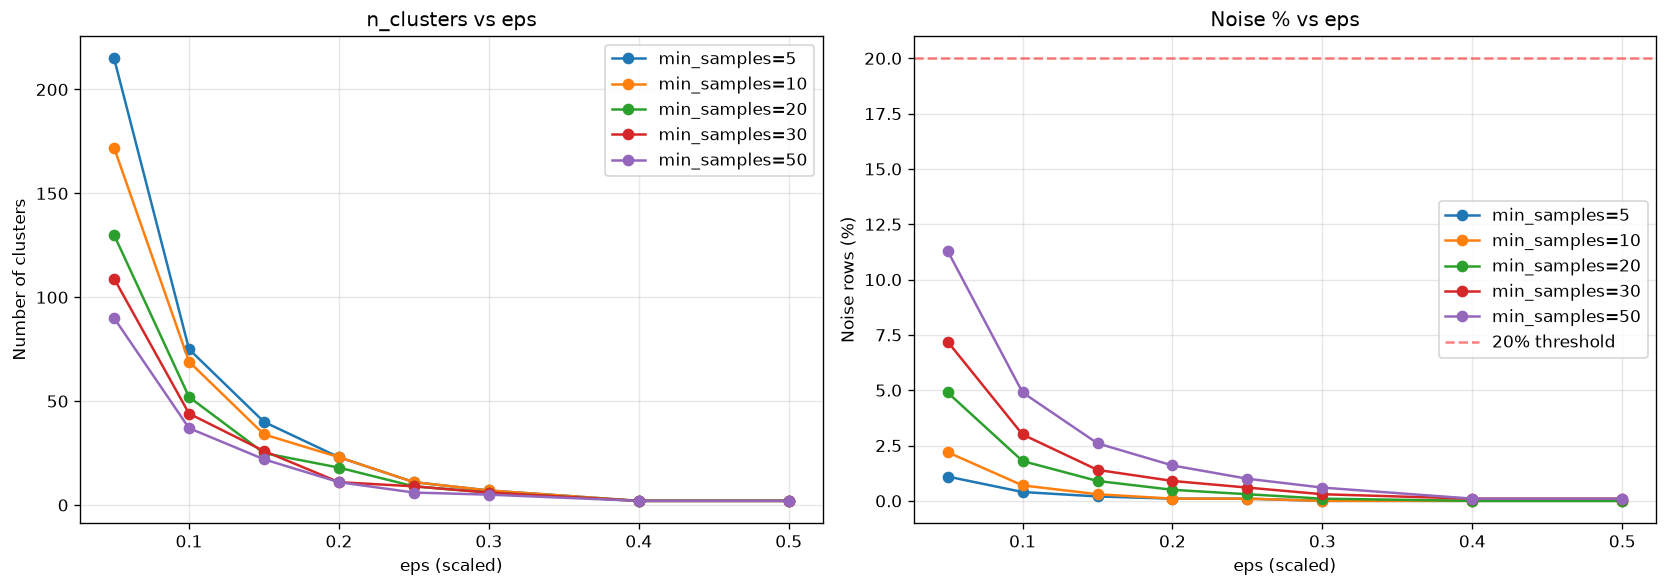

Saved: data/processed/cluster_tuning_elbow.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ms in MIN_SAMPLES_VALUES:
    subset = results[results['min_samples'] == ms].sort_values('eps')
    axes[0].plot(subset['eps'], subset['n_clusters'], marker='o', label=f'min_samples={ms}')
    axes[1].plot(subset['eps'], subset['noise_pct'], marker='o', label=f'min_samples={ms}')

axes[0].set_title('n_clusters vs eps')
axes[0].set_xlabel('eps (scaled)')
axes[0].set_ylabel('Number of clusters')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Noise % vs eps')
axes[1].set_xlabel('eps (scaled)')
axes[1].set_ylabel('Noise rows (%)')
axes[1].axhline(y=20, color='red', linestyle='--', alpha=0.5, label='20% threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'cluster_tuning_elbow.png', dpi=120)
plt.show()
print('Saved: data/processed/cluster_tuning_elbow.png')

## Cell 8 — Plot: silhouette score heatmap
**What this cell does**: Heatmap of silhouette scores across eps × min_samples.

**What to look for**: Brighter = higher silhouette = better-separated clusters.
Balance silhouette against noise_pct and n_clusters — we want:
- Silhouette ≥ 0.3 (decent separation)
- Noise < 20% (not too many unclassified violations)
- n_clusters: 50–250 (geographically meaningful zones)

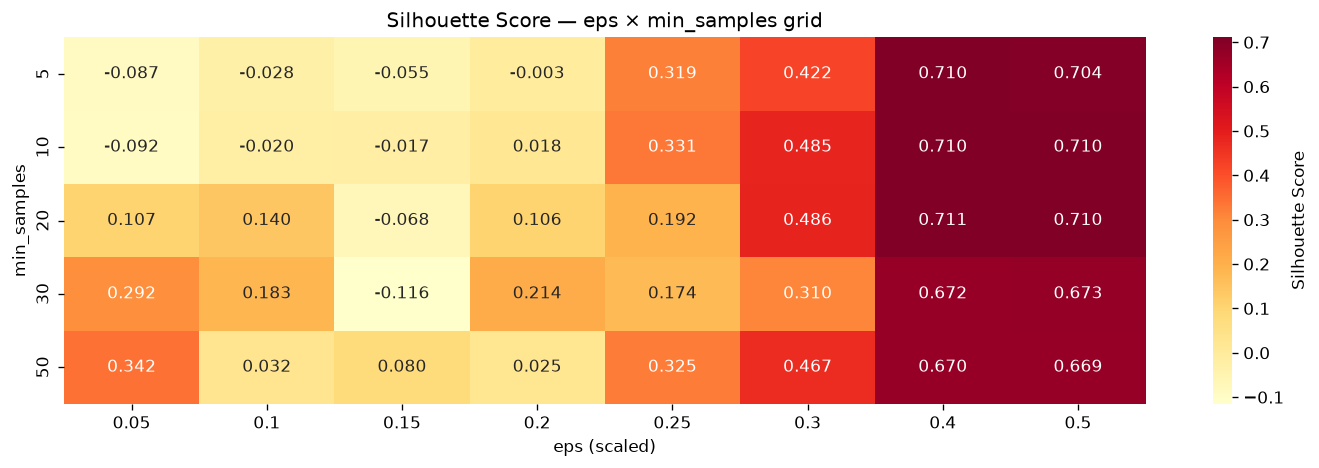

Saved: data/processed/cluster_tuning_heatmap.png


In [8]:
import seaborn as sns

pivot = results.pivot_table(
    values='silhouette_score',
    index='min_samples',
    columns='eps',
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Silhouette Score'},
)
ax.set_title('Silhouette Score — eps × min_samples grid')
ax.set_xlabel('eps (scaled)')
ax.set_ylabel('min_samples')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'cluster_tuning_heatmap.png', dpi=120)
plt.show()
print('Saved: data/processed/cluster_tuning_heatmap.png')

## Cell 9 — Selection guidance
**What this cell does**: Filters to candidates meeting the three criteria and prints a ranked shortlist.

**You must decide**: Look at Cell 7 and Cell 8, pick the eps + min_samples you want to commit, then edit Cell 10.

In [9]:
# Filter to candidates meeting all three criteria
SILHOUETTE_MIN  = 0.30   # Must have decent cluster separation
NOISE_MAX_PCT   = 20.0   # No more than 20% noise rows
N_CLUSTERS_MIN  = 50     # At least 50 zones (geographic granularity)
N_CLUSTERS_MAX  = 300    # Not more than 300 zones (manageable)

candidates = results[
    (results['silhouette_score'] >= SILHOUETTE_MIN) &
    (results['noise_pct']        <= NOISE_MAX_PCT) &
    (results['n_clusters']       >= N_CLUSTERS_MIN) &
    (results['n_clusters']       <= N_CLUSTERS_MAX)
].copy()

if candidates.empty:
    print('No candidates met ALL criteria. Relaxing noise threshold to 30%...')
    candidates = results[
        (results['silhouette_score'] >= SILHOUETTE_MIN) &
        (results['noise_pct']        <= 30.0) &
        (results['n_clusters']       >= N_CLUSTERS_MIN)
    ].copy()

print(f'{len(candidates)} candidates meet criteria:')
print(candidates.to_string(index=False))
print(f'\n>>> RECOMMENDED: eps={candidates.iloc[0]["eps"]}, min_samples={candidates.iloc[0]["min_samples"]}')
print(f'    n_clusters={candidates.iloc[0]["n_clusters"]}, silhouette={candidates.iloc[0]["silhouette_score"]}, noise={candidates.iloc[0]["noise_pct"]}%')

1 candidates meet criteria:
 eps  min_samples  n_clusters  n_noise  noise_pct  silhouette_score  avg_cluster_size
0.05           50          90     5647       11.3            0.3415             492.8

>>> RECOMMENDED: eps=0.05, min_samples=50.0
    n_clusters=90.0, silhouette=0.3415, noise=11.3%


## Cell 10 — ⚠️ COMMIT PARAMS (edit before running)
**What this cell does**: Records the chosen eps and min_samples.

**ACTION REQUIRED**: After reviewing Cells 7–9, edit `CHOSEN_EPS` and `CHOSEN_MIN_SAMPLES` below, then run this cell.

**Do NOT proceed to 03_clustering.ipynb before running this cell.**

In [11]:
# ── EDIT THESE VALUES based on Cells 7-9 output ──────────────────
CHOSEN_EPS          = candidates.iloc[0]['eps']            # e.g. 0.20
CHOSEN_MIN_SAMPLES  = int(candidates.iloc[0]['min_samples'])  # e.g. 10
# ─────────────────────────────────────────────────────────────────

chosen_row = results[
    (results['eps'] == CHOSEN_EPS) &
    (results['min_samples'] == CHOSEN_MIN_SAMPLES)
].iloc[0]

print('=== COMMITTED DBSCAN PARAMS ===')
print(f'  eps              : {CHOSEN_EPS}')
print(f'  min_samples      : {CHOSEN_MIN_SAMPLES}')
print(f'  n_clusters       : {chosen_row["n_clusters"]}')
print(f'  noise_pct        : {chosen_row["noise_pct"]}%')
print(f'  silhouette_score : {chosen_row["silhouette_score"]}')
print()
print('Next: copy these values into configs/model.yaml under the dbscan section,')
print('then run notebooks/03_clustering.ipynb to apply on the full dataset.')

=== COMMITTED DBSCAN PARAMS ===
  eps              : 0.05
  min_samples      : 50
  n_clusters       : 90.0
  noise_pct        : 11.3%
  silhouette_score : 0.3415

Next: copy these values into configs/model.yaml under the dbscan section,
then run notebooks/03_clustering.ipynb to apply on the full dataset.


## Summary

**What was done**:
- DBSCAN grid search: eps × min_samples on 50k-row sample
- Evaluated: n_clusters, noise%, silhouette score
- Plotted: elbow curve + silhouette heatmap
- Chosen params recorded above

**What was saved**:
- `data/processed/cluster_tuning_results.parquet`
- `data/processed/cluster_tuning_elbow.png`
- `data/processed/cluster_tuning_heatmap.png`

**Next step**:
1. Add chosen eps + min_samples to `configs/model.yaml` (dbscan section)
2. Run `notebooks/03_clustering.ipynb` — full DBSCAN + CIS computation

In [12]:
print('=== Cluster Tuning Summary ===')
print(f'  Grid combos tested  : {len(results)}')
print(f'  Sample size         : {SAMPLE_SIZE:,}')
print(f'  Chosen eps          : {CHOSEN_EPS}')
print(f'  Chosen min_samples  : {CHOSEN_MIN_SAMPLES}')
print(f'  Expected n_clusters : {int(chosen_row["n_clusters"])}')
print(f'  Expected noise      : {chosen_row["noise_pct"]}%')
print(f'  Silhouette score    : {chosen_row["silhouette_score"]}')
print(f'  Saved               : data/processed/cluster_tuning_results.parquet')
print(f'  Next notebook       : notebooks/03_clustering.ipynb')

=== Cluster Tuning Summary ===
  Grid combos tested  : 40
  Sample size         : 50,000
  Chosen eps          : 0.05
  Chosen min_samples  : 50
  Expected n_clusters : 90
  Expected noise      : 11.3%
  Silhouette score    : 0.3415
  Saved               : data/processed/cluster_tuning_results.parquet
  Next notebook       : notebooks/03_clustering.ipynb
